In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage as ski 
from pathlib import Path

def s_topple_once(grid, mask):
    """
    Cells with value >= 2 lose 2 and give +1 to two random N,S,E,W neighbours.
    We delete grains leaving the boundary are deleted.
    """
    grid = np.asarray(grid)
    H, W = grid.shape
    m = mask.astype(grid.dtype)
    topples = np.sum(m,dtype=int)

    #copy grid and perform the -2 for each toppled site
    out = grid.copy()
    out -= 2*m

    #bounding box padding to drop grains that leave the system
    bb = np.zeros((H+2, W+2), dtype=grid.dtype)
    bb[1:-1, 1:-1] = out

    xs,ys = np.where(m==1)
    updates = np.random.randint(0,4,(topples,2))
    xs += 1
    ys += 1

    for i in range(topples):
        for j in [0,1]:
            if updates[i, j] == 0:
                bb[xs[i],  ys[i] + 1] += 1 #North
            elif updates[i, j] == 1:
                bb[xs[i],  ys[i] - 1] += 1 #South
            elif updates[i, j] == 2:
                bb[xs[i] + 1,  ys[i]] += 1 #East
            elif updates[i, j] == 3:
                bb[xs[i] - 1,  ys[i]] += 1 #West
    out = bb[1:-1,1:-1]
    new_mask = (out >= 2)
    return out, new_mask, topples

def SOC(n, N):
    sandbox_hist = np.zeros((n,N,N))
    #sandbox = np.random.randint(0,2,size=(N,N))
    sandbox = np.zeros((N,N))
    count = np.zeros(n)
    grid_height = np.zeros(n)
    L = np.zeros(n)


    for _ in range(n):
        i,j = np.random.randint(0,N, size = 2)
        min_x = i
        max_x = i
        min_y = j
        max_y = j

        sandbox[i,j] += 1
        mask = sandbox >= 2
        while mask.any():
            # sites that will topple this iteration (in current coordinates)
            xs, ys = np.where(mask)

            if xs.size:

                # update total span bounding box
                min_x = min(min_x, int(xs.min()))
                max_x = max(max_x, int(xs.max()))
                min_y = min(min_y, int(ys.min()))
                max_y = max(max_y, int(ys.max()))

            sandbox, mask, topples = s_topple_once(sandbox, mask)
            count[_] += topples
        L_x = max_x-min_x+1
        L_y = max_y-min_y+1
        L[_] = max(L_x, L_y)
        grid_height[_] = np.mean(sandbox)
        sandbox_hist[_] = sandbox
    return sandbox_hist, count, grid_height, L


In [ ]:
'''
grids25, aval_L25, grid_height25, L_25 = SOC(5000,25)
grids50, aval_L50, grid_height50, L_50 = SOC(6000,50)
grids100, aval_L100, grid_height100, L_100 = SOC(10000, 100)
grids200, aval_L200, grid_height200, L_200 = SOC(40000,200)
'''

In [ ]:
from pathlib import Path


# output directory
outdir = Path("soc_data")
outdir.mkdir(exist_ok=True)
# --- Save everything ---
np.save(outdir / "aval_L25.npy", aval_L25)
np.save(outdir / "grid_height25.npy", grid_height25)
np.save(outdir / "L_25.npy", np.array(L_25))

np.save(outdir / "aval_L50.npy", aval_L50)
np.save(outdir / "grid_height50.npy", grid_height50)
np.save(outdir / "L_50.npy", np.array(L_50))

np.save(outdir / "aval_L100.npy", aval_L100)
np.save(outdir / "grid_height100.npy", grid_height100)
np.save(outdir / "L_100.npy", np.array(L_100))

np.save(outdir / "aval_L200.npy", aval_L200)
np.save(outdir / "grid_height200.npy", grid_height200)
np.save(outdir / "L_200.npy", np.array(L_200))

print(f"✅ All simulation data saved to: {outdir.resolve()}")

✅ All simulation data saved to: C:\Users\lucq0\OneDrive\Skrivebord\Complex Physics\src\soc_data


In [2]:
# Directory containing saved data
outdir = Path("soc_data")

# --- Load everything ---
aval_L25 = np.load(outdir / "aval_L25.npy", allow_pickle=True)
grid_height25 = np.load(outdir / "grid_height25.npy", allow_pickle=True)
L_25 = np.load(outdir / "L_25.npy", allow_pickle=True)

aval_L50 = np.load(outdir / "aval_L50.npy", allow_pickle=True)
grid_height50 = np.load(outdir / "grid_height50.npy", allow_pickle=True)
L_50 = np.load(outdir / "L_50.npy", allow_pickle=True)

aval_L100 = np.load(outdir / "aval_L100.npy", allow_pickle=True)
grid_height100 = np.load(outdir / "grid_height100.npy", allow_pickle=True)
L_100 = np.load(outdir / "L_100.npy", allow_pickle=True)

aval_L200 = np.load(outdir / "aval_L200.npy", allow_pickle=True)
grid_height200 = np.load(outdir / "grid_height200.npy", allow_pickle=True)
L_200 = np.load(outdir / "L_200.npy", allow_pickle=True)

print("✅ All simulation data loaded successfully!")

✅ All simulation data loaded successfully!


Text(0, 0.5, '(C) Mean lattice height | $\\overline{h}$')

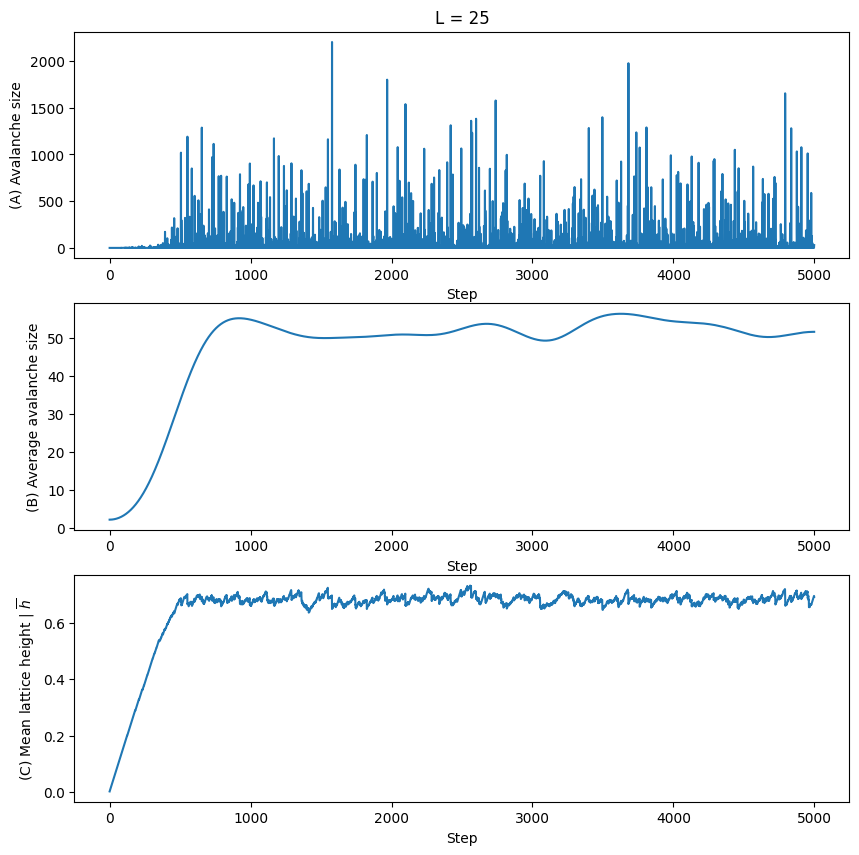

In [21]:
plt.figure(figsize=(10, 10))

plt.subplot(3, 1, 1)
plt.plot(aval_L25)
plt.title("L = 25")
plt.xlabel("Step")
plt.ylabel("(A) Avalanche size")

plt.subplot(3, 1, 2)
mean_aval25 = ski.filters.gaussian(aval_L25, sigma = (200), mode='reflect')
plt.plot(mean_aval25)
plt.xlabel("Step")
plt.ylabel("(B) Average avalanche size")

plt.subplot(3, 1, 3)
plt.plot(grid_height25)
plt.xlabel("Step")
plt.ylabel(r"(C) Mean lattice height | $\overline{h}$")


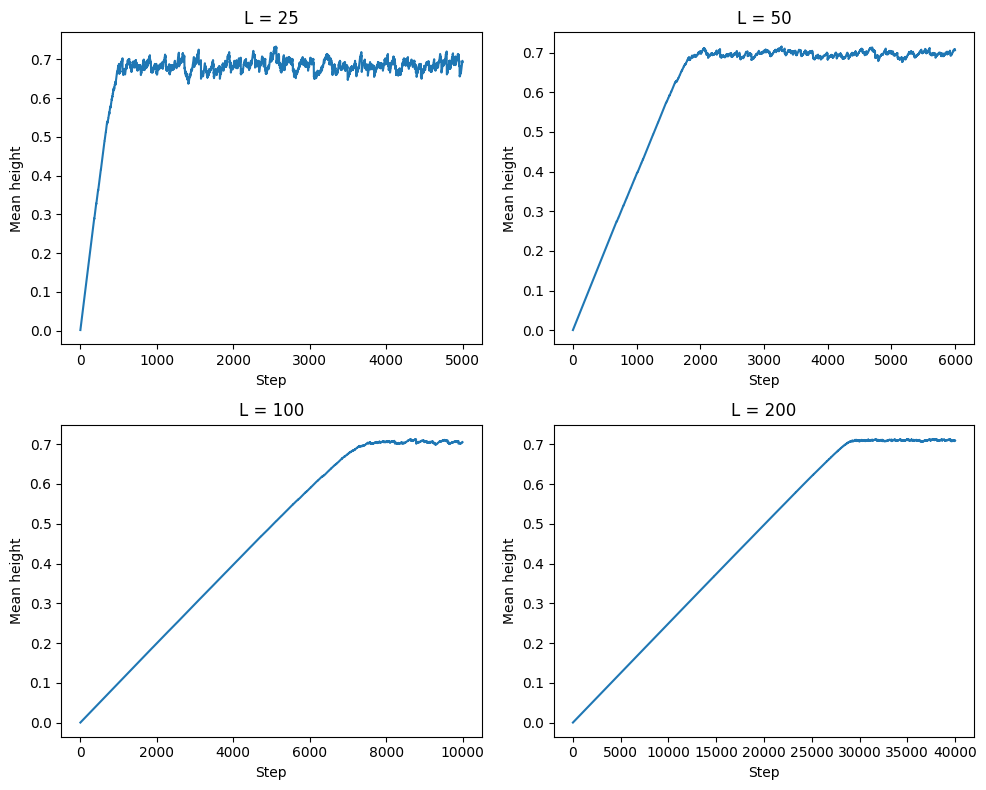

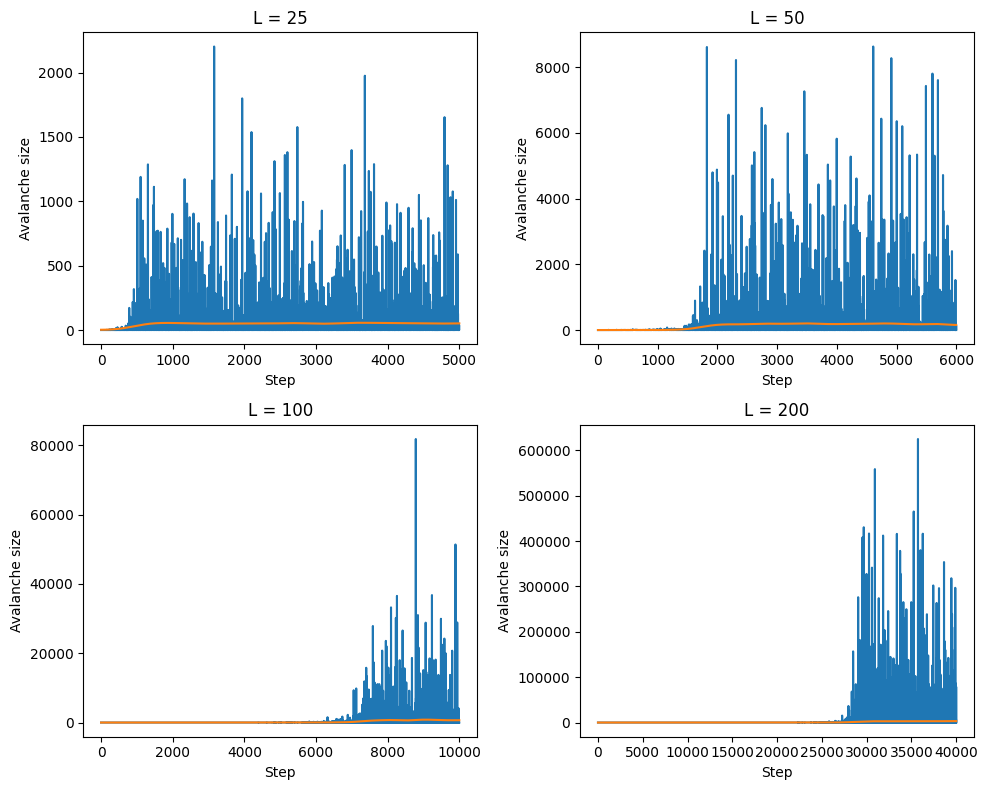

In [6]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(grid_height25)
plt.title("L = 25")
plt.xlabel("Step")
plt.ylabel("Mean height")

plt.subplot(2, 2, 2)
plt.plot(grid_height50)
plt.title("L = 50")
plt.xlabel("Step")
plt.ylabel("Mean height")

plt.subplot(2, 2, 3)
plt.plot(grid_height100)
plt.title("L = 100")
plt.xlabel("Step")
plt.ylabel("Mean height")

plt.subplot(2, 2, 4)
plt.plot(grid_height200)
plt.title("L = 200")
plt.xlabel("Step")
plt.ylabel("Mean height")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(aval_L25)
mean_aval25 = ski.filters.gaussian(aval_L25, sigma = (200), mode='reflect')
plt.plot(mean_aval25)
plt.title("L = 25")
plt.xlabel("Step")
plt.ylabel("Avalanche size")

plt.subplot(2, 2, 2)
plt.plot(aval_L50)
mean_aval50 = ski.filters.gaussian(aval_L50, sigma = (200), mode='reflect')
plt.plot(mean_aval50)
plt.title("L = 50")
plt.xlabel("Step")
plt.ylabel("Avalanche size")

plt.subplot(2, 2, 3)
plt.plot(aval_L100)
mean_aval100 = ski.filters.gaussian(aval_L100, sigma = (200), mode='reflect')
plt.plot(mean_aval100)
plt.title("L = 100")
plt.xlabel("Step")
plt.ylabel("Avalanche size")

plt.subplot(2, 2, 4)
plt.plot(aval_L200)
mean_aval200 = ski.filters.gaussian(aval_L200, sigma = (1000), mode='reflect')
plt.plot(mean_aval200)
plt.title("L = 200")
plt.xlabel("Step")
plt.ylabel("Avalanche size")

plt.tight_layout()
plt.show()


In [23]:
aval_L25_n = aval_L25[1000:]
aval_L50_n = aval_L50[2000:]
aval_L100_n = aval_L100[8000:]
aval_L200_n = aval_L200[30000:]

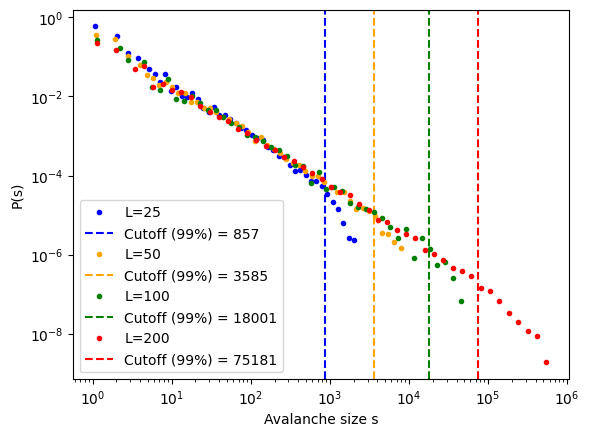

In [25]:
def log_hist(data, bins=50):
    bins = np.logspace(np.log10(min(data)), np.log10(max(data)), bins)
    hist, edges = np.histogram(data, bins=bins, density=True)
    centers = np.sqrt(edges[1:] * edges[:-1])
    return centers, hist
k = 0
colors = ["blue", "orange", "green", "red"]
for L, aval in zip([25,50,100,200], [aval_L25_n, aval_L50_n, aval_L100_n, aval_L200_n]):
    mask = aval > 0
    s_cutoff = np.percentile(aval, 99)
    s, P = log_hist(aval[mask])
    
    plt.plot(s, P,'.',color = colors[k], label=f"L={L}")
    plt.axvline(s_cutoff, color=colors[k], linestyle='--', linewidth=1.5, label=f'Cutoff (99%) = {s_cutoff:.0f}')
    k+=1

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Avalanche size s")
plt.ylabel("P(s)")
plt.legend(loc='lower left')
plt.show()


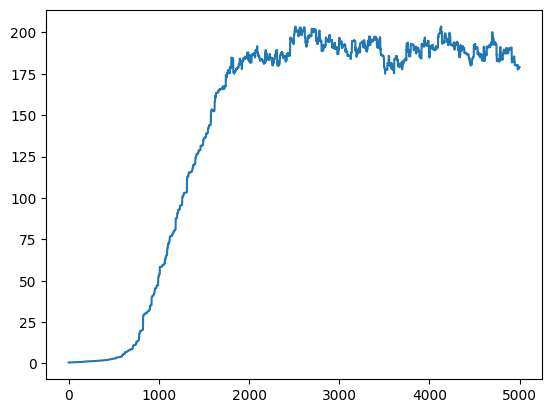

In [34]:
plt.plot(np.convolve(aval_L50, np.ones(1000)/1000, mode='valid'))


In [32]:
print(25*np.sqrt(25))

125.0


In [1]:

plt.plot(counts100)
plt.show()

plt.plot(L_100, counts100, '.')
plt.xscale("log")
plt.yscale("log")
plt.show()

x = L_100
y = counts100
mask = (y > 0) & (x > 0)
x = x[mask]
y = y[mask]

logx = np.log(x)
logy = np.log(y)

# linear regression in log-log space
coeffs = np.polyfit(logx, logy, 1)
slope, intercept = coeffs   # slope = -alpha, intercept = log(a)

alpha = slope
a = np.exp(intercept)
print(f"Fit: y ≈ {a:.3f} * x^({alpha:.3f})")

plt.plot(grid_height100)
plt.show()

Hist = plt.hist(counts100[8000:], bins=400, density=True)
y0 = Hist[0]
x0 = Hist[1]
plt.xscale("log")
plt.yscale("log")
plt.show()

NameError: name 'plt' is not defined

In [132]:
grids50, counts50, grid_height50, L_50 = SOC(10000,50)

In [125]:
np.save("Grids200", grids200)
np.save("Counts200", counts200)
np.save("grid_height200", grid_height200)

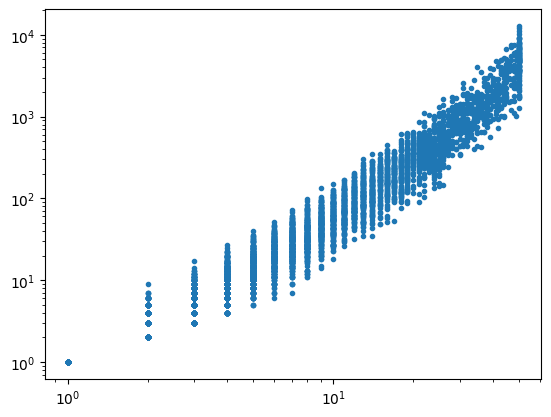

Fit: y ≈ 0.607 * x^(2.045)


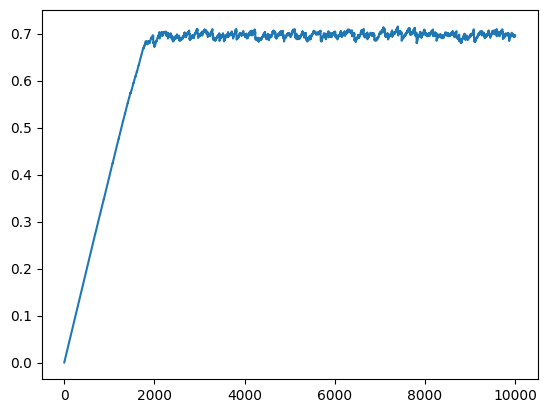

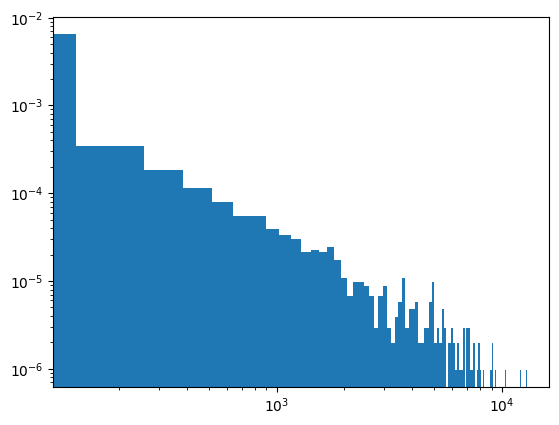

In [ ]:

plt.plot(counts50)
plt.show()

plt.plot(L_50, counts50, '.')
plt.xscale("log")
plt.yscale("log")
plt.show()

x = L_50
y = counts50
mask = (y > 0) & (x > 0)
x = x[mask]
y = y[mask]

logx = np.log(x)
logy = np.log(y)

# linear regression in log-log space
coeffs = np.polyfit(logx, logy, 1)
slope, intercept = coeffs   # slope = -alpha, intercept = log(a)

alpha = slope
a = np.exp(intercept)
print(f"Fit: y ≈ {a:.3f} * x^({alpha:.3f})")

plt.plot(grid_height50)
plt.show()

Hist = plt.hist(counts50[2000:], bins=100, density=True)
y0 = Hist[0]
x0 = Hist[1]
plt.xscale("log")
plt.yscale("log")
plt.show()

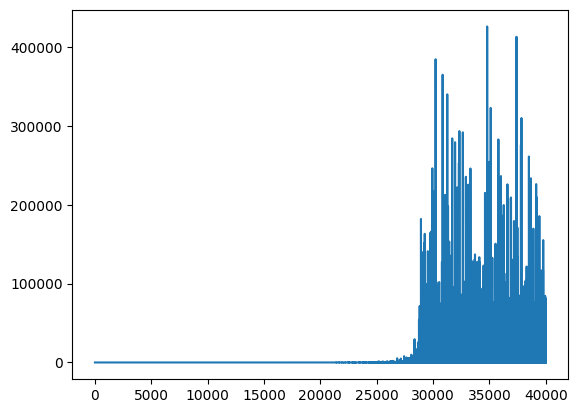

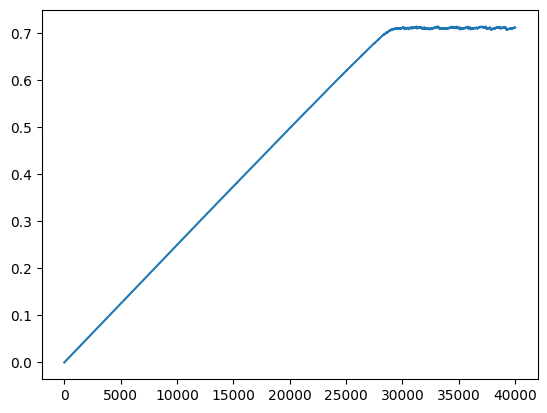

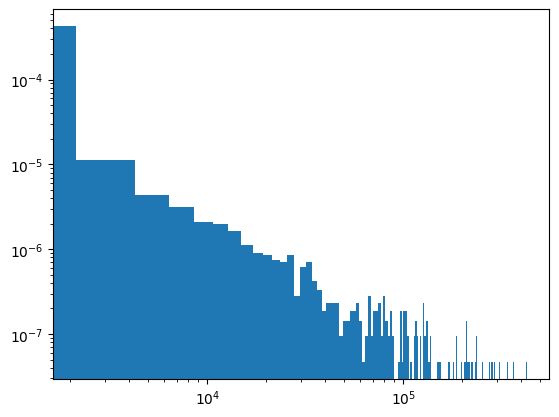

In [ ]:

plt.plot(counts200)
plt.show()

plt.plot(grid_height200)
plt.show()

Hist = plt.hist(counts200[30000:], bins=200, density=True)
y0 = Hist[0]
x0 = Hist[1]
plt.xscale("log")
plt.yscale("log")
plt.show()

Fit: y ≈ 4184.874 * x^(-1.199)


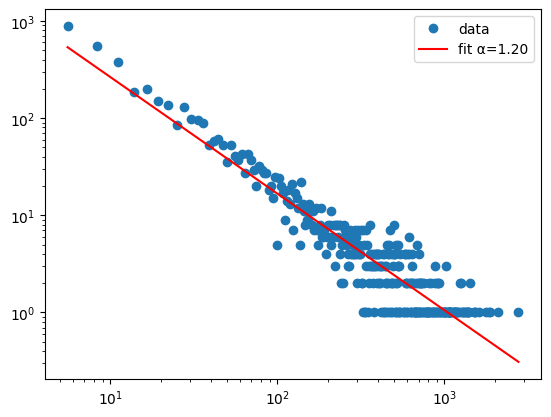

In [ ]:
x0 = x0[1:]
x = x0[1:]
y = y0[1:]
mask = (y > 0) & (x > 0)
x = x[mask]
y = y[mask]

logx = np.log(x)
logy = np.log(y)

# linear regression in log-log space
coeffs = np.polyfit(logx, logy, 1)
slope, intercept = coeffs   # slope = -alpha, intercept = log(a)

alpha = -slope
a = np.exp(intercept)
print(f"Fit: y ≈ {a:.3f} * x^(-{alpha:.3f})")

plt.loglog(x, y, 'o', label="data")
plt.loglog(x, a * x**(-alpha), 'r-', label=f"fit α={alpha:.2f}")
plt.legend()
plt.show()
